In [ ]:
# importing tha libraries which are depending here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [ ]:
# data collection and processing.
# loading our data to a pandas data frame.
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [ ]:
# for seeing the datas available we will print the first 5 rows.
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
  # printing the last five rows to see the date
gold_data.tail() # here tail is used to print the last five rows

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [ ]:
# now we gonna fine how many no. rowas and column is there.
gold_data.shape

(2290, 6)

In [ ]:
# now we gonna find some basic information about the data.
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
# checking the  number of missing vlue
gold_data.isnull().sum() #the output represents that there is no missing value present in data.

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
# now we gonna know more about statistical information regarding our data.
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [ ]:
# now we gonna find the analysis of oyr data.
# first we gonna find the coorelation of our data. 1. positive correaltion 2. negative correlation
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

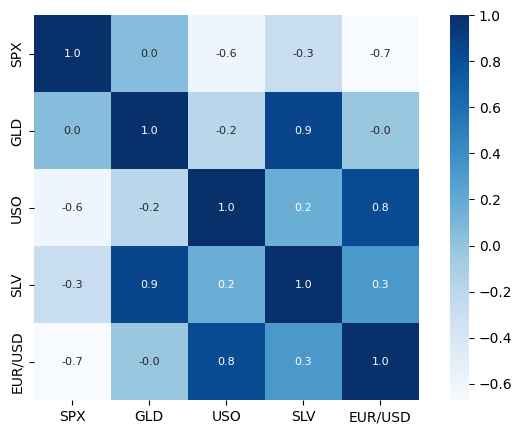

In [ ]:
# now we are constructing the heat map to understand the correaltion.
plt.figure(figsize = (8,5))
sns.heatmap(correlation, cbar =True , square =True , fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [ ]:


# now we gonna see the correlation value of gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_13002/1460891913.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='red')


<Axes: xlabel='GLD', ylabel='Density'>

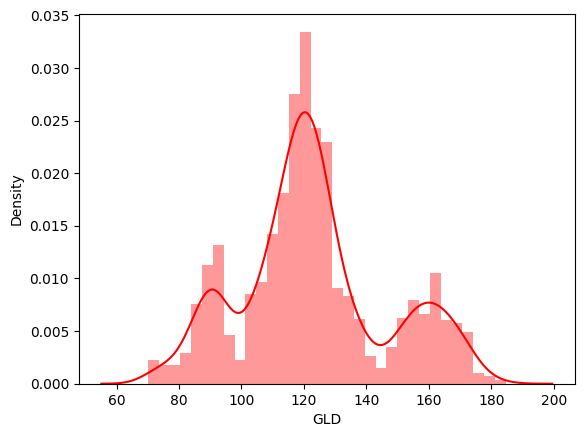

In [ ]:
# now we gonna check the distribution of the gold price.
sns.distplot(gold_data['GLD'],color='red')

In [ ]:
# now we gonna spliting the features and target.
x= gold_data.drop(['Date','GLD'],axis=1)
y= gold_data['GLD']
print(x)


              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [ ]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [ ]:
# now we gonna split the train and test dataset.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=2)

In [ ]:
# now we train our model.
# we will ue noe random forest.
regressor = RandomForestRegressor(n_estimators=100)

In [ ]:
# training the model
regressor.fit(x_train,y_train)


RandomForestRegressor()

In [ ]:
# now we gonna evalute our model.
# prediction on test data.
test_data_prediction = regressor.predict(x_test)

In [ ]:
print(test_data_prediction)

[168.59199953  82.16469985 115.6585006  127.78460078 120.77950101
 154.86709789 150.69099893 126.06690019 117.64489874 126.06300051
 116.72130107 171.7805008  141.79499926 167.76839839 115.29509994
 117.88930021 139.59440322 169.71070029 159.60880261 160.16229972
 155.15110053 125.24690058 176.39549921 157.52810306 125.22100038
  93.80329994  77.58479994 120.68509992 119.12879949 167.48199997
  88.22680034 125.1425998   91.08460065 117.78550033 121.15709897
 136.53830148 115.47210134 115.08570068 148.03439971 107.70170077
 104.01750229  87.20419778 126.48100055 118.03250014 151.9738988
 119.52860029 108.24409981 108.01669833  93.2592002  127.2789975
  75.25770027 113.79519952 121.32710017 111.22369909 118.94329876
 120.8844996  159.65710088 166.64560133 146.73949623  85.87069854
  94.32550033  86.88929908  90.64320018 118.97640074 126.43520057
 127.6449     170.22800051 122.27399951 117.32259923  98.67420028
 168.28690146 143.05139806 132.04310234 121.24660249 121.0384994
 119.93260029

In [ ]:

# now we gonna use R SQUARED error
error_score = metrics.r2_score(y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9891975468205078


In [ ]:
# comparing the actual valye with the predicted value.
y_test = list(y_test)

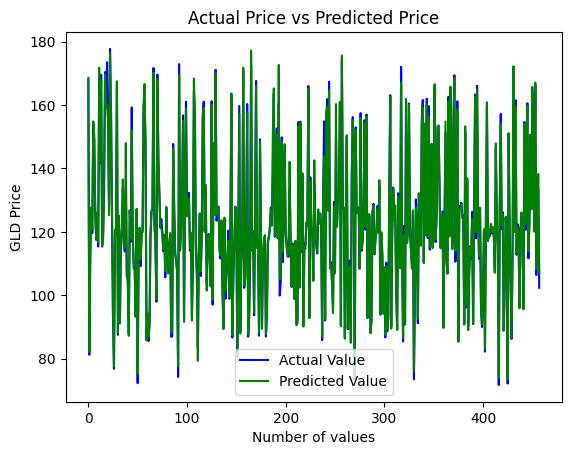

In [ ]:
plt.plot(y_test, color='blue', label = 'Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()